In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

In [3]:
df = pd.read_csv("bank.csv")

### Display First 5 Rows

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Check Dataset Shape

In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 11162
Number of Columns : 17


### Display Column Names

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

### Check Data Types

In [7]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

### Check Missing Values

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

### Check Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### Check Unique Values

In [11]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

### Display Numerical Columns

In [12]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
print(numerical_columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


### Display Categorical Columns

In [13]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')


### Create a Data Description Table (Professional)

In [14]:
def data_description(dataframe):
    description = pd.DataFrame({
        'Columns': dataframe.columns,
        'Data Type': dataframe.dtypes.values,
        'Unique Values': dataframe.nunique().values,
        'Missing Values': dataframe.isnull().sum().values
    })
    return description

data_description(df)

,Columns,Data Type,Unique Values,Missing Values
0,age,int64,76,0
1,job,object,12,0
2,marital,object,3,0
3,education,object,4,0
4,default,object,2,0
5,balance,int64,3805,0
6,housing,object,2,0
7,loan,object,2,0
8,contact,object,3,0
9,day,int64,31,0


### Check Memory Usage

In [15]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 6.4 MB


### Display Random Samples

In [16]:
df.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
4993,57,unknown,married,unknown,no,19268,no,no,unknown,23,oct,301,1,-1,0,unknown,yes
1824,29,management,married,tertiary,no,0,yes,no,cellular,6,may,667,2,-1,0,unknown,yes
10323,36,entrepreneur,married,primary,no,177,yes,no,unknown,12,may,63,5,-1,0,unknown,no
2926,38,admin.,married,secondary,no,1767,yes,no,cellular,12,nov,893,7,-1,0,unknown,yes
7129,33,management,married,tertiary,no,32,no,no,cellular,29,aug,27,7,-1,0,unknown,no
9115,54,management,married,tertiary,no,122,yes,no,cellular,22,jul,126,3,-1,0,unknown,no
5556,33,unemployed,single,secondary,no,233,yes,no,unknown,8,may,221,4,-1,0,unknown,no
189,50,unemployed,married,secondary,no,3674,yes,no,unknown,30,may,886,3,-1,0,unknown,yes
4067,28,technician,single,tertiary,no,11862,no,no,cellular,21,oct,549,2,238,13,other,yes
9243,36,technician,single,secondary,no,144,no,no,cellular,26,may,87,1,308,2,failure,no


# Step 2: Data Cleaning & Preparation

### Create a Copy of the Original Dataset

In [17]:
# Create a copy of the dataset
clean_df = df.copy()

### Check Missing Values

In [18]:
clean_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

### Check Duplicate Rows

In [19]:
clean_df.duplicated().sum()

np.int64(0)

### Check Data Types

In [20]:
clean_df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

### Check Unique Values

In [22]:
clean_df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

In [23]:
clean_df['job'].unique()

array(['admin.', 'technician', 'services', 'management', 'retired',
       'blue-collar', 'unemployed', 'entrepreneur', 'housemaid',
       'unknown', 'self-employed', 'student'], dtype=object)

In [24]:
clean_df['education'].unique()

array(['secondary', 'tertiary', 'primary', 'unknown'], dtype=object)

In [25]:
clean_df['education'].unique()

array(['secondary', 'tertiary', 'primary', 'unknown'], dtype=object)

### Standardize Text Columns

In [26]:
text_columns = clean_df.select_dtypes(include='object').columns

for col in text_columns:
    clean_df[col] = clean_df[col].str.strip().str.lower()

### Check for Outliers

In [27]:
numerical_columns = clean_df.select_dtypes(include=['int64','float64']).columns
numerical_columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

#### Draw Boxplots

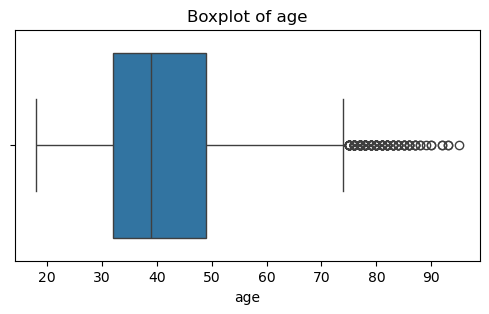

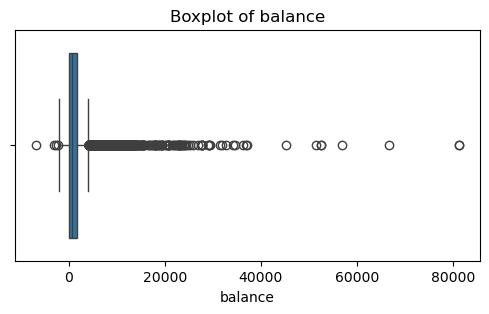

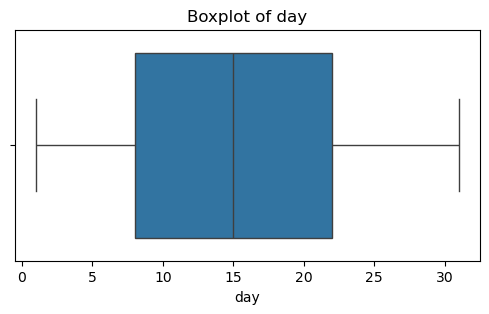

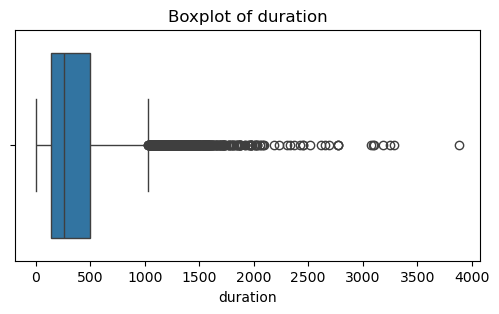

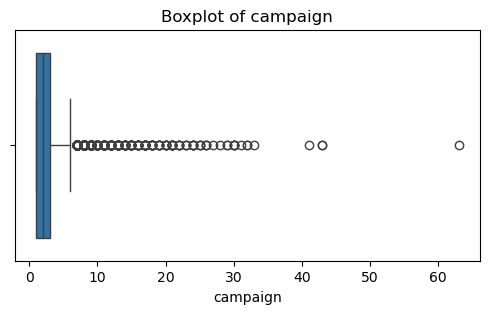

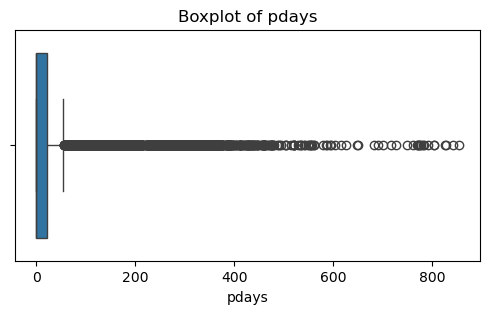

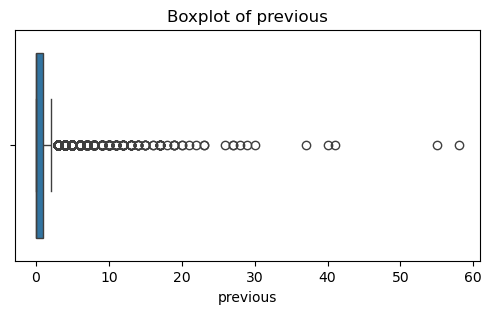

In [28]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=clean_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Remove Outliers (IQR Method)

In [29]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

In [30]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [31]:
clean_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [32]:
clean_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Save the Cleaned Dataset

In [33]:
clean_df.to_csv("cleaned_bank.csv", index=False)

### Create a Data Cleaning Summary

In [34]:
print("Original Shape :", df.shape)
print("Cleaned Shape :", clean_df.shape)

print("\nMissing Values:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(clean_df.duplicated().sum())

Original Shape : (11162, 17)
Cleaned Shape : (11162, 17)

Missing Values:
0

Duplicate Rows:
0


## Data Cleaning Summary
   #### Created a copy of the original dataset.
   #### Checked for missing values and handled them appropriately.
   #### Removed duplicate records.
   #### Verified and corrected data types where necessary.
   #### Standardized text values by trimming spaces and converting to lowercase.
   #### Examined numerical columns for outliers using boxplots.
   #### Saved the cleaned dataset for further analysis.

# Step 3: Exploratory Data Analysis (EDA)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Load the Cleaned Dataset

In [36]:
clean_df = pd.read_csv("cleaned_bank.csv")

### Display Basic Information

In [38]:
clean_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [39]:
clean_df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [40]:
clean_df.shape

(11162, 17)

In [41]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [42]:
clean_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### Target Variable Analysis

In [43]:
clean_df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

#### Visualization

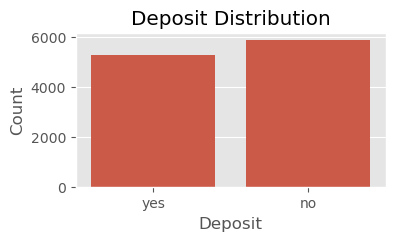

In [69]:
plt.figure(figsize=(4,2))
sns.countplot(data=clean_df, x='deposit')
plt.title("Deposit Distribution")
plt.xlabel("Deposit")
plt.ylabel("Count")
plt.show()
#Compare how many customers subscribed (yes) versus did not (no).

### Numerical Columns Distribution

In [47]:
numerical_columns = clean_df.select_dtypes(include=['int64','float64']).columns
numerical_columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

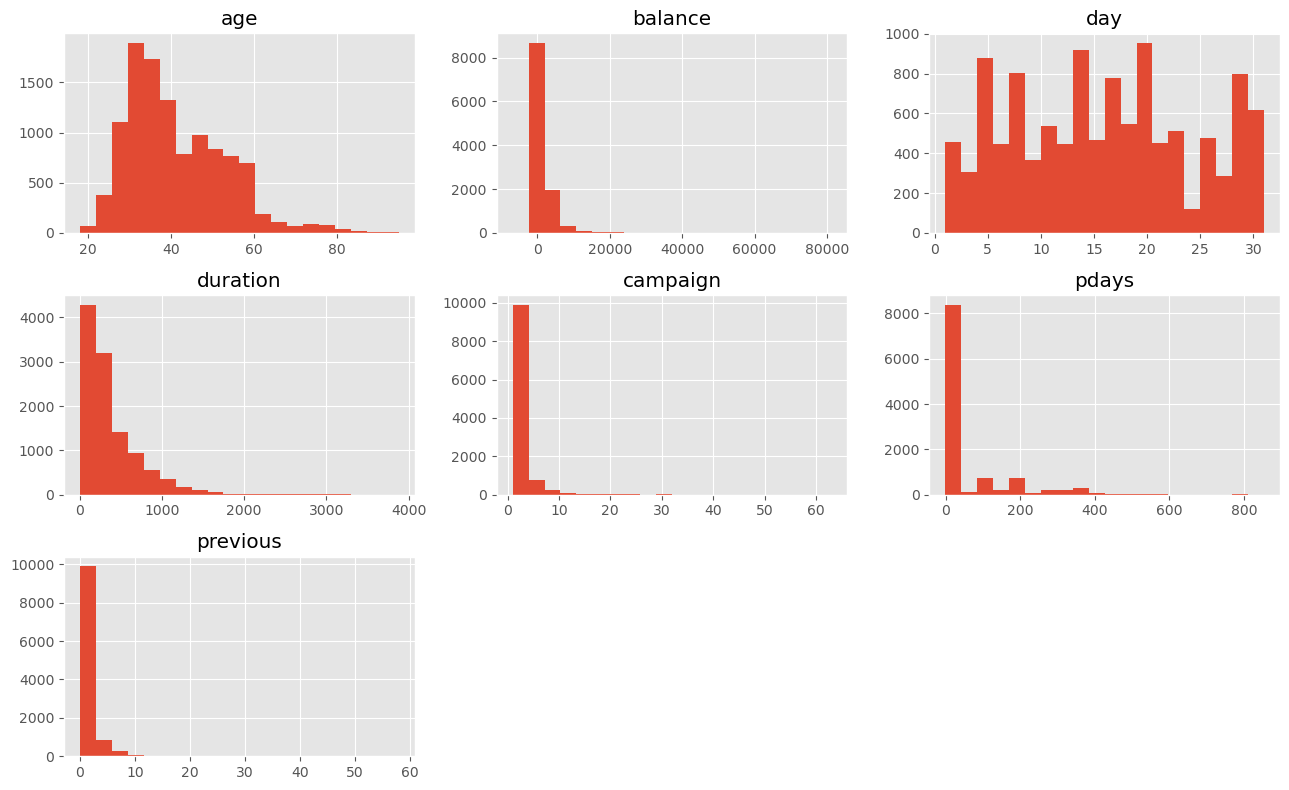

In [70]:
#Histogram
clean_df[numerical_columns].hist(figsize=(13,8), bins=20)
plt.tight_layout()
plt.show()

### Age Distribution

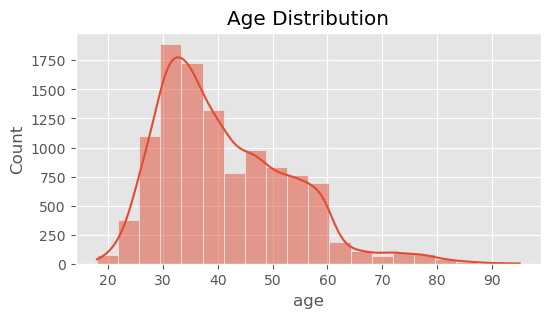

In [71]:
plt.figure(figsize=(6,3))
sns.histplot(clean_df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

### Balance Distribution

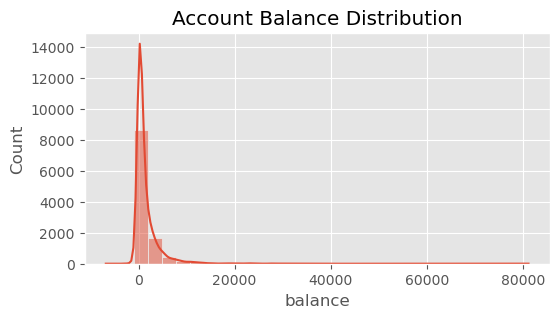

In [72]:
plt.figure(figsize=(6,3))
sns.histplot(clean_df['balance'], bins=30, kde=True)

plt.title("Account Balance Distribution")
plt.show()

### Job Distribution

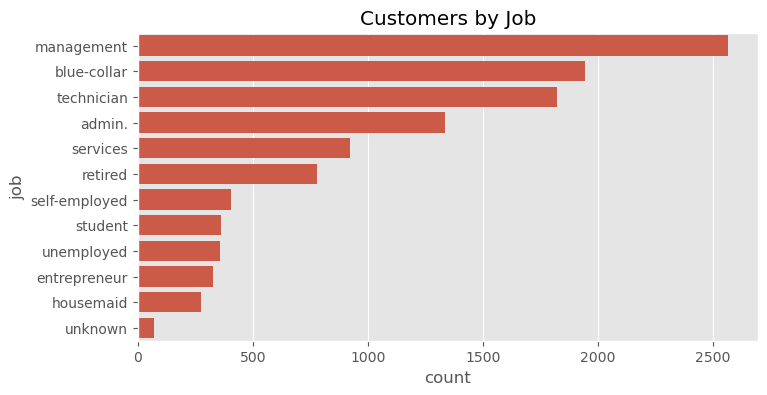

In [73]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=clean_df,
    y='job',
    order=clean_df['job'].value_counts().index
)

plt.title("Customers by Job")
plt.show()

### Marital Status

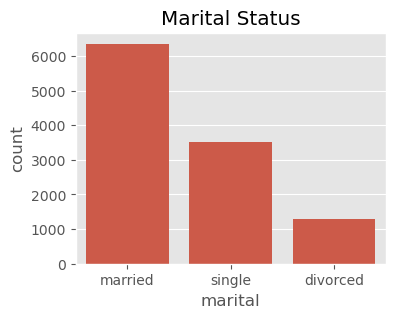

In [75]:
plt.figure(figsize=(4,3))

sns.countplot(data=clean_df, x='marital')

plt.title("Marital Status")
plt.show()

### Education

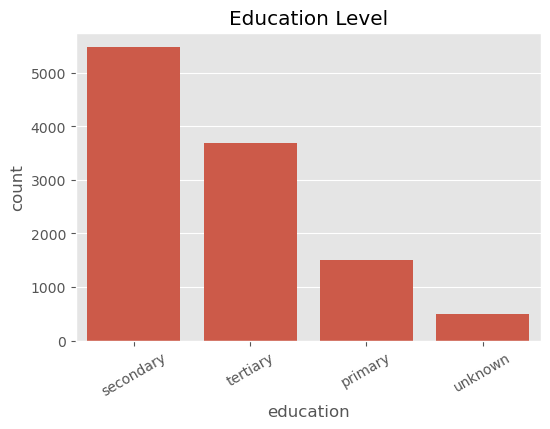

In [76]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=clean_df,
    x='education',
    order=clean_df['education'].value_counts().index
)

plt.title("Education Level")
plt.xticks(rotation=30)

plt.show()

### Housing Loan

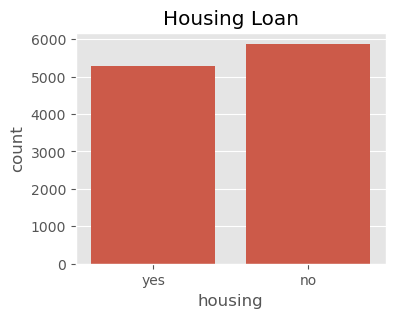

In [77]:
plt.figure(figsize=(4,3))

sns.countplot(data=clean_df, x='housing')

plt.title("Housing Loan")
plt.show()

### Personal Loan

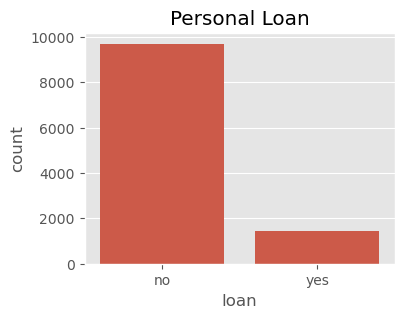

In [68]:
plt.figure(figsize=(4,3))

sns.countplot(data=clean_df, x='loan')

plt.title("Personal Loan")
plt.show()

### Deposit by Job

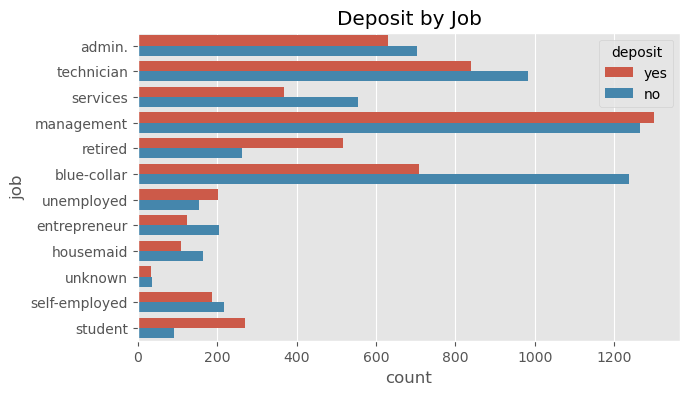

In [78]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=clean_df,
    y='job',
    hue='deposit'
)

plt.title("Deposit by Job")
plt.show()

### Deposit by Education

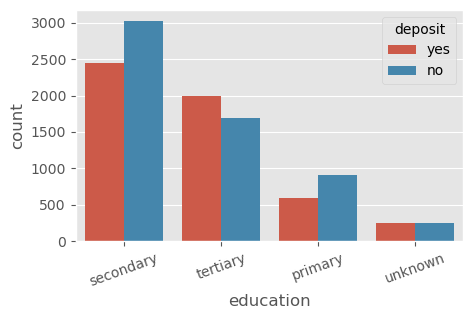

In [66]:
plt.figure(figsize=(5,3))

sns.countplot(
    data=clean_df,
    x='education',
    hue='deposit'
)

plt.xticks(rotation=20)
plt.show()

### Deposit by Marital Status

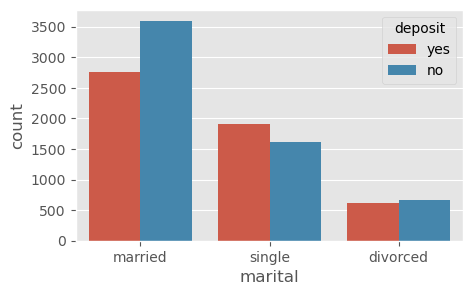

In [65]:
plt.figure(figsize=(5,3))

sns.countplot(
    data=clean_df,
    x='marital',
    hue='deposit'
)
plt.show()

### Correlation Matrix

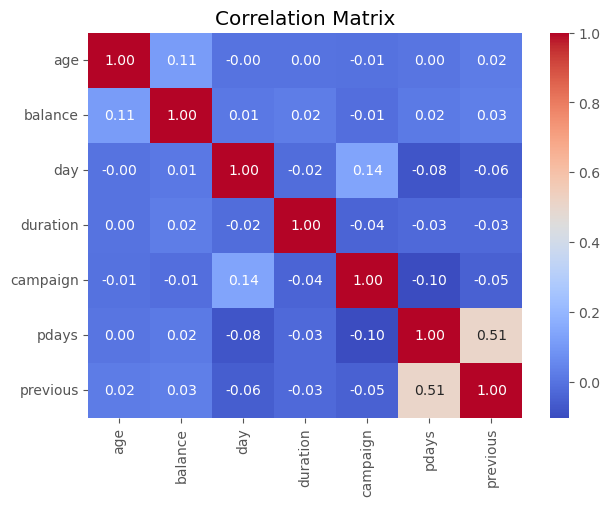

In [80]:
plt.figure(figsize=(7,5))

corr = clean_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Pairplot

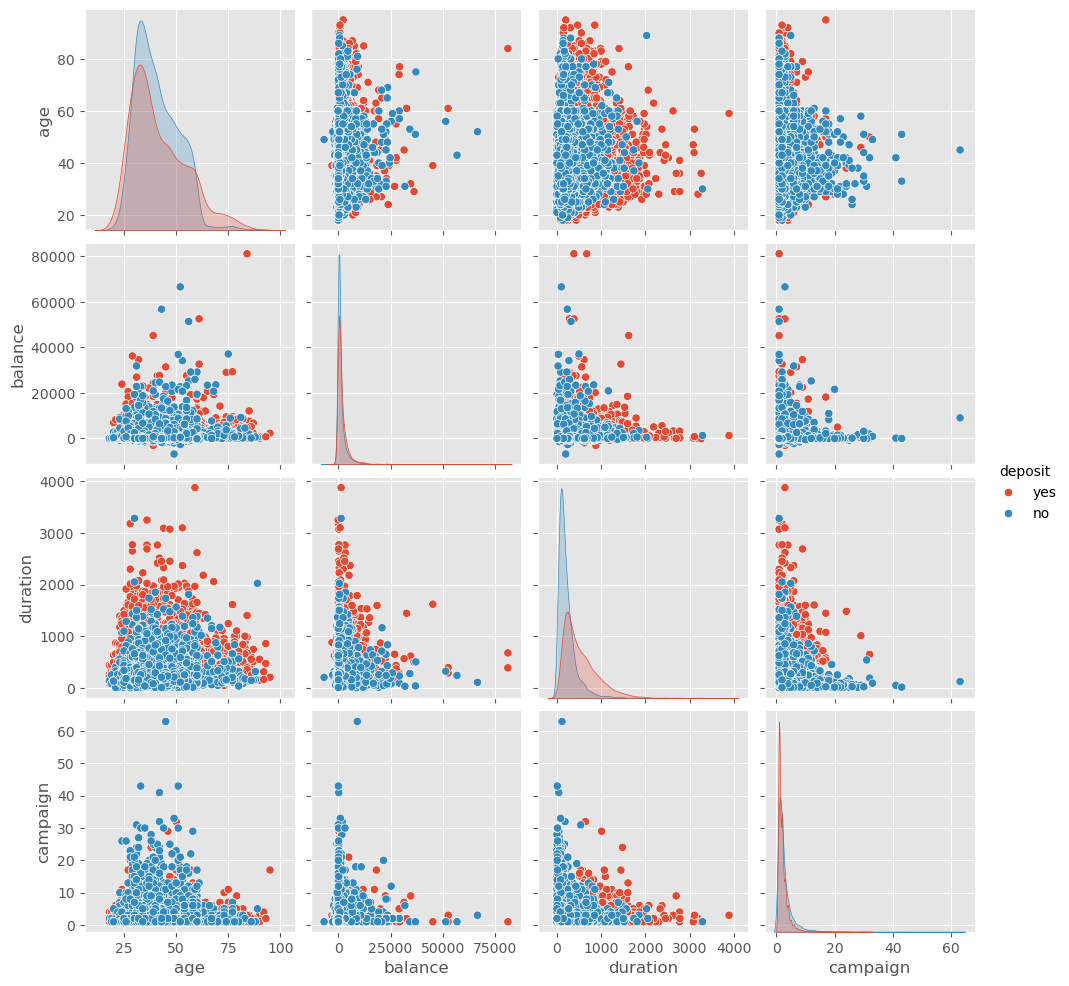

In [81]:
sns.pairplot(
    clean_df[['age','balance','duration','campaign','deposit']],
    hue='deposit'
)
plt.show()

### Average Balance by Job

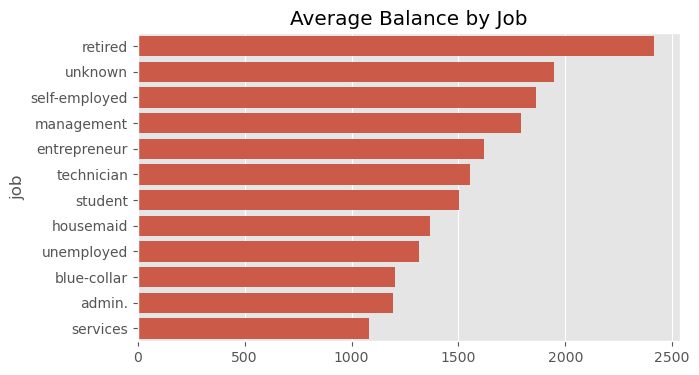

In [83]:
job_balance = clean_df.groupby('job')['balance'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))

sns.barplot(
    x=job_balance.values,
    y=job_balance.index
)

plt.title("Average Balance by Job")
plt.show()

### Average Age by Deposit

In [84]:
clean_df.groupby('deposit')['age'].mean()

deposit
no     40.837391
yes    41.670070
Name: age, dtype: float64

### Top 10 Jobs

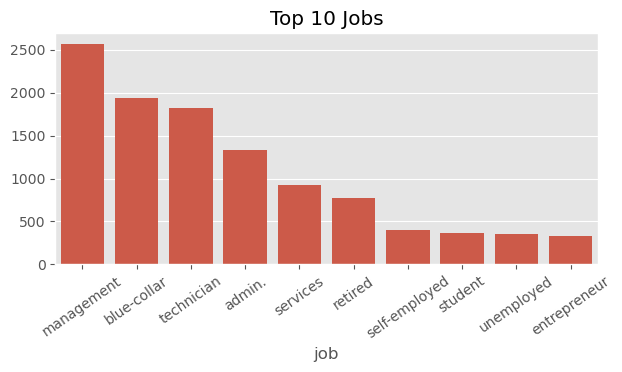

In [87]:
top_jobs = clean_df['job'].value_counts().head(10)

plt.figure(figsize=(7,3))

sns.barplot(
    x=top_jobs.index,
    y=top_jobs.values
)

plt.xticks(rotation=35)

plt.title("Top 10 Jobs")
plt.show()

# Business Insights

1. Most customers did not subscribe to a term deposit.
2. The majority of customers are in the 'management' and 'blue-collar' job categories.
3. Customers with higher call durations appear more likely to subscribe.
4. Housing loans are common among customers.
5. Customers with larger account balances tend to have a higher subscription rate.
6. Most customers fall between 30 and 50 years of age.
7. Married customers make up the largest group in the dataset.
8. There is only a weak linear correlation between most numerical variables.

# Feature Engineering
  ### Objective
    Create new columns that provide more business value than the original data.

### Create a Copy

In [88]:
feature_df = clean_df.copy()

### Create Age Groups
Instead of using exact ages, group customers into age categories.

In [89]:
feature_df['Age_Group'] = pd.cut(
    feature_df['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

feature_df[['age','Age_Group']].head()

,age,Age_Group
0,59,51-60
1,56,51-60
2,41,41-50
3,55,51-60
4,54,51-60


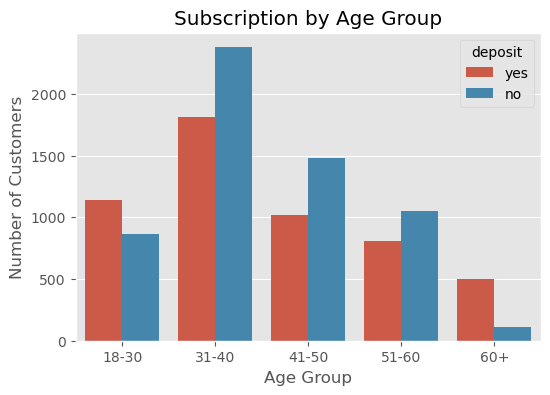

In [98]:
# Subscription by Age Group
plt.figure(figsize=(6,4))

sns.countplot(
    data=feature_df,
    x='Age_Group',
    hue='deposit'
)

plt.title("Subscription by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

### Balance Category
Group customers based on their account balance.

In [90]:
feature_df['Balance_Category'] = pd.cut(
    feature_df['balance'],
    bins=[-10000,0,1000,5000,1000000],
    labels=['Negative','Low','Medium','High']
)
feature_df[['balance','Balance_Category']].head()

,balance,Balance_Category
0,2343,Medium
1,45,Low
2,1270,Medium
3,2476,Medium
4,184,Low


### Loan Status
Combine housing and personal loan information.

In [92]:
feature_df['Loan_Status'] = feature_df['housing'] + "_" + feature_df['loan']
feature_df[['housing','loan','Loan_Status']].head()

,housing,loan,Loan_Status
0,yes,no,yes_no
1,no,no,no_no
2,yes,no,yes_no
3,yes,no,yes_no
4,no,no,no_no


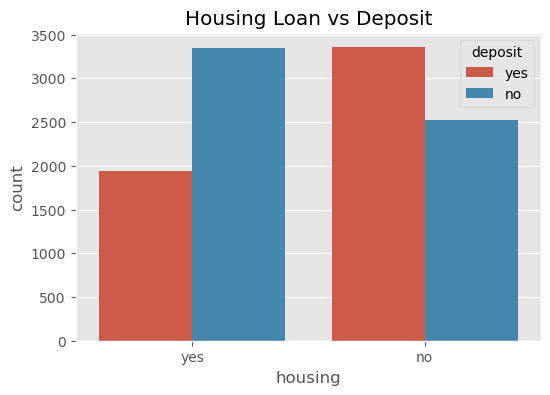

In [99]:
# Housing Loan vs Deposit
plt.figure(figsize=(6,4))

sns.countplot(
    data=feature_df,
    x='housing',
    hue='deposit'
)

plt.title("Housing Loan vs Deposit")

plt.show()

### High Balance Customer

In [93]:
feature_df['High_Balance'] = np.where(
    feature_df['balance']>=5000,
    "Yes",
    "No"
)
feature_df[['balance','High_Balance']].head()

,balance,High_Balance
0,2343,No
1,45,No
2,1270,No
3,2476,No
4,184,No


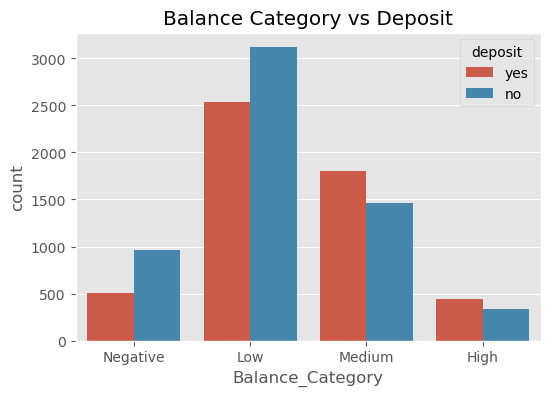

In [101]:
# Balance Category Analysis
plt.figure(figsize=(6,4))

sns.countplot(
    data=feature_df,
    x='Balance_Category',
    hue='deposit'
)

plt.title("Balance Category vs Deposit")
plt.show()

### Save the Feature Engineered Dataset

In [102]:
feature_df.to_csv("feature_engineered_bank.csv", index=False)

In [95]:
feature_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'Age_Group', 'Balance_Category',
       'Previous_Contact', 'Loan_Status', 'High_Balance'],
      dtype='object')